# Stage 07 — Paired-CV Statistical Significance Tests

**Owner:** Sandesh Shahi (Analysis Lead)

**Why this notebook exists.** Assessment 2 rubric item 4 explicitly asks us to *"perform appropriate statistical tests (e.g. t-tests or other relevant tests) to compare model performance and assess the statistical significance of your findings. Clearly state your hypotheses and interpret the test results."*

**Design.**
- Each candidate model pair is evaluated on the **same** stratified K-fold splits.
- The per-fold score differences are tested with `scipy.stats.ttest_rel` (paired t-test).
- Hypotheses:
  - $H_0$: the two models have equal mean score across folds — any observed difference is CV noise.
  - $H_1$: the two models have different mean scores — one is truly better.
- Significance level $\alpha = 0.05$.

**Model pairs.**
- **RQ1:** OLS vs Ridge (scored by $R^2$).
- **RQ2:** Random Forest vs Naive Bayes (scored by accuracy).

**Inputs.** Checkpoints from notebook 03.

**Outputs.** `data/processed/checkpoints/07_ttest_results.json`, also written to `outputs/tables/paired_ttest_results.json`.

## 1. Setup

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score, accuracy_score

from src import config, evaluation, reporting

def _load(name):
    p = config.CHECKPOINT_DIR / name
    return pd.read_parquet(p) if p.exists() else pd.read_csv(p.with_suffix('.csv'))

X = _load("03_X.parquet")
y_reg = _load("03_y_reg.parquet").iloc[:, 0]
y_cls = _load("03_y_cls.parquet").iloc[:, 0]
mask = y_cls.notna()
X_cls, y_cls_clean = X.loc[mask].reset_index(drop=True), y_cls.loc[mask].astype(int).reset_index(drop=True)
print("Ready:", X.shape, "for regression;", X_cls.shape, "for classification.")

Ready: (7971, 24) for regression; (7971, 24) for classification.


## 2. RQ1 — OLS vs Ridge (paired-CV on R²)

Ridge is OLS with L2 regularisation. If Ridge wins significantly it suggests the OLS coefficients were destabilised by multicollinearity; if OLS wins or the test is non-significant, the OLS interpretation is safe.

In [2]:
ttest_reg = evaluation.paired_t_test_cv(
    LinearRegression(),
    Ridge(alpha=1.0, random_state=config.RANDOM_SEED),
    X, y_reg,
    scoring_fn=r2_score,
    stratify=False,
    name_a="OLS",
    name_b="Ridge",
)
print(f"OLS   fold R²: {['%.4f' % s for s in ttest_reg['scores_a']]}   mean={ttest_reg['mean_a']:.4f}")
print(f"Ridge fold R²: {['%.4f' % s for s in ttest_reg['scores_b']]}   mean={ttest_reg['mean_b']:.4f}")
print(f"\nt = {ttest_reg['t_statistic']:.3f}   p = {ttest_reg['p_value']:.4f}")
print("Significant at α = 0.05:", ttest_reg['significant_at_0.05'])
print("Better model (by mean R²):", ttest_reg['better_model'])

21:46:30 | INFO    | src.evaluation | Paired t-test OLS vs Ridge: mean_a=0.4442 mean_b=0.4443 t=-0.624 p=0.5664
OLS   fold R²: ['0.4596', '0.3875', '0.4376', '0.4857', '0.4505']   mean=0.4442
Ridge fold R²: ['0.4597', '0.3879', '0.4380', '0.4854', '0.4504']   mean=0.4443

t = -0.624   p = 0.5664
Significant at α = 0.05: False
Better model (by mean R²): Ridge


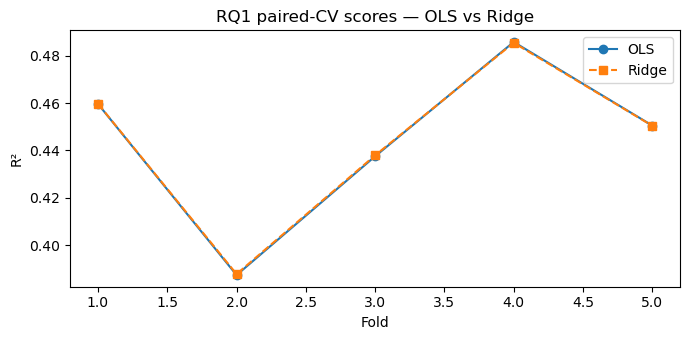

In [3]:
# Visualise per-fold scores
fig, ax = plt.subplots(figsize=(7, 3.5))
folds = np.arange(1, len(ttest_reg['scores_a']) + 1)
ax.plot(folds, ttest_reg['scores_a'], "o-", label="OLS")
ax.plot(folds, ttest_reg['scores_b'], "s--", label="Ridge")
ax.set_xlabel("Fold"); ax.set_ylabel("R²")
ax.set_title("RQ1 paired-CV scores — OLS vs Ridge")
ax.legend(); plt.tight_layout(); plt.show()

## 3. RQ2 — Random Forest vs Naive Bayes (paired-CV on accuracy)

In [4]:
ttest_cls = evaluation.paired_t_test_cv(
    RandomForestClassifier(n_estimators=300, class_weight="balanced",
                           random_state=config.RANDOM_SEED, n_jobs=-1),
    GaussianNB(),
    X_cls, y_cls_clean,
    scoring_fn=accuracy_score,
    stratify=True,
    name_a="RandomForest",
    name_b="NaiveBayes",
)
print(f"RF fold acc: {['%.4f' % s for s in ttest_cls['scores_a']]}   mean={ttest_cls['mean_a']:.4f}")
print(f"NB fold acc: {['%.4f' % s for s in ttest_cls['scores_b']]}   mean={ttest_cls['mean_b']:.4f}")
print(f"\nt = {ttest_cls['t_statistic']:.3f}   p = {ttest_cls['p_value']:.4f}")
print("Significant at α = 0.05:", ttest_cls['significant_at_0.05'])
print("Better model (by mean accuracy):", ttest_cls['better_model'])

21:46:34 | INFO    | src.evaluation | Paired t-test RandomForest vs NaiveBayes: mean_a=0.7576 mean_b=0.7315 t=4.430 p=0.0114
RF fold acc: ['0.7555', '0.7641', '0.7503', '0.7710', '0.7472']   mean=0.7576
NB fold acc: ['0.7304', '0.7202', '0.7340', '0.7371', '0.7359']   mean=0.7315

t = 4.430   p = 0.0114
Significant at α = 0.05: True
Better model (by mean accuracy): RandomForest


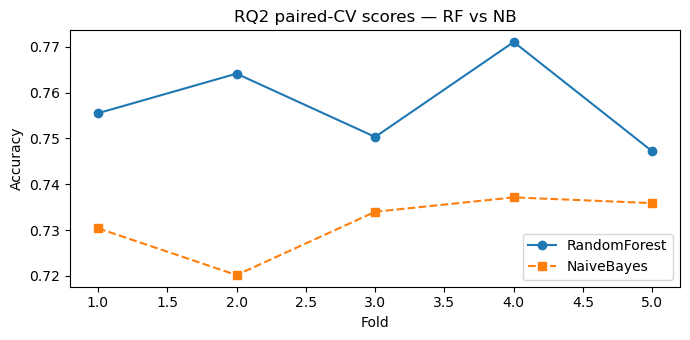

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
folds = np.arange(1, len(ttest_cls['scores_a']) + 1)
ax.plot(folds, ttest_cls['scores_a'], "o-", label="RandomForest")
ax.plot(folds, ttest_cls['scores_b'], "s--", label="NaiveBayes")
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy")
ax.set_title("RQ2 paired-CV scores — RF vs NB")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Consolidated results table

In [6]:
summary = pd.DataFrame([
    {
        "comparison": "RQ1 — OLS vs Ridge (R²)",
        "mean_a": ttest_reg["mean_a"], "mean_b": ttest_reg["mean_b"],
        "t": ttest_reg["t_statistic"], "p": ttest_reg["p_value"],
        "sig_0.05": ttest_reg["significant_at_0.05"], "better": ttest_reg["better_model"],
    },
    {
        "comparison": "RQ2 — RF vs NB (accuracy)",
        "mean_a": ttest_cls["mean_a"], "mean_b": ttest_cls["mean_b"],
        "t": ttest_cls["t_statistic"], "p": ttest_cls["p_value"],
        "sig_0.05": ttest_cls["significant_at_0.05"], "better": ttest_cls["better_model"],
    },
]).round(4)
summary

,comparison,mean_a,mean_b,t,p,sig_0.05,better
0,RQ1 — OLS vs Ridge (R²),0.4442,0.4443,-0.6240,0.5664,False,Ridge
1,RQ2 — RF vs NB (accuracy),0.7576,0.7315,4.4299,0.0114,True,RandomForest


## 5. Checkpoint

In [7]:
results = {"rq1_ols_vs_ridge": ttest_reg, "rq2_rf_vs_nb": ttest_cls}
with open(config.CHECKPOINT_DIR / "07_ttest_results.json", "w") as f:
    json.dump(results, f, indent=2)
reporting.write_ttest_results(ttest_reg, ttest_cls)
print("Saved t-test results.")

21:46:35 | INFO    | src.reporting | Paired t-test results → D:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\outputs\tables\paired_ttest_results.json
Saved t-test results.


## How to phrase this on the slide

*"Using 5-fold cross-validation we compared our primary model against a baseline on identical folds and applied a paired t-test (H0: equal mean performance). For RQ2, Random Forest achieved mean accuracy `X` vs Naive Bayes `Y`, t = `t`, p = `p` — we {reject / fail to reject} H0 at α = 0.05, concluding the improvement {is / is not} statistically significant."*

**Next:** `08_reporting.ipynb` — consolidate everything into the final metrics summary.